# Simulazione d'esame Laboratorio di Programmazione 2
## Simulazione B

## Esercizio 1

Crea un vettore NumPy con i **prezzi al chilo** (in euro) di 5 prodotti al supermercato: **3.20, 5.80, 1.50, 7.40, 2.90**

1. Calcola il **prezzo medio** dei prodotti.

2. Il prodotto da **7.40 €/kg** subisce un **aumento del 15%**.
   - Modifica il vettore per applicare l'aumento.
   - Controlla se il nuovo valore (**8.51 €**) è presente nell'array.

3. Il prodotto da **1.50 €/kg** è in **promozione: sconto del 20%**.
   - Applica la modifica.

4. Tutti i prodotti con prezzo **superiore alla media** (calcolata dopo le modifiche precedenti) subiscono un **ulteriore rincaro del 3%**.
   - Aggiorna il vettore usando l'indicizzazione booleana.

5. Calcola la **somma totale** se un cliente compra **1 kg di ogni prodotto**, prima e dopo tutte le modifiche.

6. Di quanto è aumentata la **spesa complessiva** rispetto al prezzo iniziale?

In [31]:
import numpy as np

prezzo_prodotti = np.array([3.20, 5.80, 1.50, 7.40, 2.90])
mean = np.mean(prezzo_prodotti)
spesa_in = np.sum(prezzo_prodotti)

print(f"Prezzo prodotti inziale: {prezzo_prodotti}")
print(f"Costo spesa inziale: {spesa_in.round(2)}")

prezzo_prodotti[3] += (prezzo_prodotti[3] * 15) /100 
prezzo_prodotti[2] -= (prezzo_prodotti[2] * 20) /100 
spesa = np.sum(prezzo_prodotti)


print(f"Prezzo prodotti primo aumento: {prezzo_prodotti}")
print(f"Costo spesa primo aumento: {spesa.round(2)}")


mean = np.mean(prezzo_prodotti)
idx = np.where(prezzo_prodotti>mean)[0]
prezzo_prodotti[idx] += prezzo_prodotti[idx] * 3 /100
spesa = np.sum(prezzo_prodotti)

print(f"Prezzo prodotti aumento del 3%: {prezzo_prodotti.round(2)}")
print(f"Costo spesa aumento 3%: {spesa.round(2)}")
print(f"Aumento complessivo spesa: {(spesa - spesa_in).round(2)}")


Prezzo prodotti inziale: [3.2 5.8 1.5 7.4 2.9]
Costo spesa inziale: 20.8
Prezzo prodotti primo aumento: [3.2  5.8  1.2  8.51 2.9 ]
Costo spesa primo aumento: 21.61
Prezzo prodotti aumento del 3%: [3.2  5.97 1.2  8.77 2.9 ]
Costo spesa aumento 3%: 22.04
Aumento complessivo spesa: 1.24


## Esercizio 2

Simula il lancio di **due dadi a 6 facce** per N giocatori e T turni.

1. Scrivi una funzione `simula_dadi(T, N)` che:
   - Simula T lanci di due dadi per N giocatori
   - Restituisce due array di lunghezza T: la **media della somma** dei due dadi ad ogni turno (su tutti i giocatori) e la **deviazione standard** della somma.

2. Esegui la simulazione con T=200 turni e N=50 giocatori.
   - Plotta la media delle somme per ogni turno.
   - Aggiungi al grafico una linea orizzontale tratteggiata al valore teorico atteso (7.0).

3. Plotta anche la deviazione standard.
   - La deviazione standard converge a un valore fisso all'aumentare dei giocatori N? Commenta brevemente.

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

def media__dev_turno(esisto_lancio):
    a = np.array(esisto_lancio)
    return np.mean(a), np.std(a)

#giocatori, turni
def simula_dadi(n, t):
    medie = []
    deviazioni = []
    for lancio in range(t):
        esisto_lancio = []
        for giocatore in range(n):
            dado1 = random.randint(1, 6)
            dado2 = random.randint(1, 6)
            esisto_lancio.append(dado1+dado2)
        media, dev = media__dev_turno(esisto_lancio)
        medie.append(media)
        deviazioni.append(dev)

    return np.array(medie), np.array(deviazioni)

medie, deviaz = simula_dadi(50, 200)

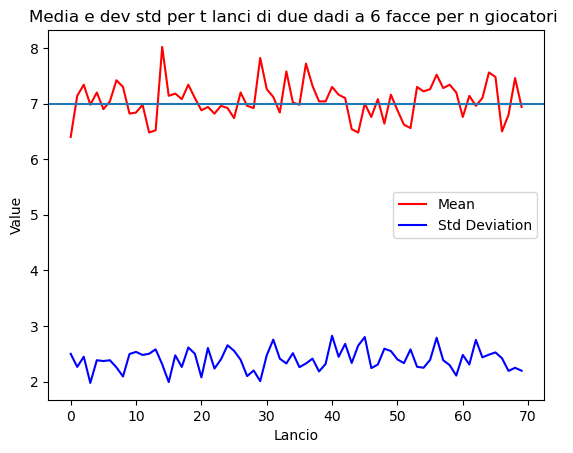

In [49]:
plt.plot(medie, color='red', label='Mean')
plt.plot(deviaz, color='blue', label='Std Deviation')
plt.axhline(7.0)
plt.title('Media e dev std per t lanci di due dadi a 6 facce per n giocatori ')
plt.xlabel('Lancio')
plt.ylabel('Value')
plt.legend()
plt.show()

## Esercizio 3

Genera una matrice `m` di dimensioni **6 x 8** con numeri interi casuali tra 1 e 100.
Usa il seed `np.random.seed(7)`.

1. Per ogni **colonna**, trova il valore **più vicino alla mediana dell'intera matrice**.

2. Sostituisci tutti i valori **maggiori di 80** con il valore **−1**, usando l'indicizzazione booleana.

3. Calcola la somma degli elementi di ogni riga **dopo** la sostituzione.

*Suggerimento*: per l'indicizzazione riga/colonna ricorda `m[righe, colonne]`.

In [96]:
import numpy as np
np.random.seed(7)

a = np.array([random.randint(1,100) for n in range(6*8)]).reshape(6,8)

print(f"Matrice:\n{a}")

mediana = np.median(a)
print(f"Mediana: {mediana}")

idx = [np.abs(i - mediana).argmin() for i in a.T]

print(f'Valore piu vicino alla mediana per ogni colonna: {a[[i for i in idx], [n for n in range(8)]]}')

a[a>80] = -1

print(f'Somma per ogni riga: {np.sum(a, axis=1)}')


Matrice:
[[42 41 41 41  7 99 39 55]
 [80 43 46 34 87 96 32 98]
 [34 27  8 22 14 41 21 10]
 [71  4 21 93 91 54 45 95]
 [80 49 77 37 89 44 57 83]
 [24 91  5 79 93  7 66 20]]
Mediana: 43.5
Valore piu vicino alla mediana per ogni colonna: [42 43 41 41 14 44 45 55]
Somma per ogni riga: [265 232 177 192 342 199]


## Esercizio 4

Utilizza il dataset `iris`, disponibile all'url = `"https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"`

Esegui un'analisi esplorativa focalizzandoti sulle misure dei petali e sepali.

1. **Visualizza le ultime 8 righe** del dataset.

2. **Calcola la media e la deviazione standard** di tutte le colonne numeriche.

3. **Crea una nuova colonna** `petal_ratio` definita come:
   $$\texttt{petal\_ratio} = \frac{\texttt{petal\_length}}{\texttt{petal\_width}}$$
   *(Attenzione ai valori nulli o zero nel denominatore!)*

4. Trova la **specie** con il `petal_ratio` **mediano** più alto.

5. **Filtra solo i fiori** con `sepal_length > 6.0` e `petal_width < 2.0`.

6. **Crea un grafico a dispersione** (`scatter`) di `petal_length` vs `petal_width`, colorando i punti per specie.

7. **Crea un boxplot** di `sepal_length` per ogni specie.

💡 *Suggerimento*: usa `hue='species'` in seaborn per differenziare le specie.

In [192]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")
df

#df.tail(8)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


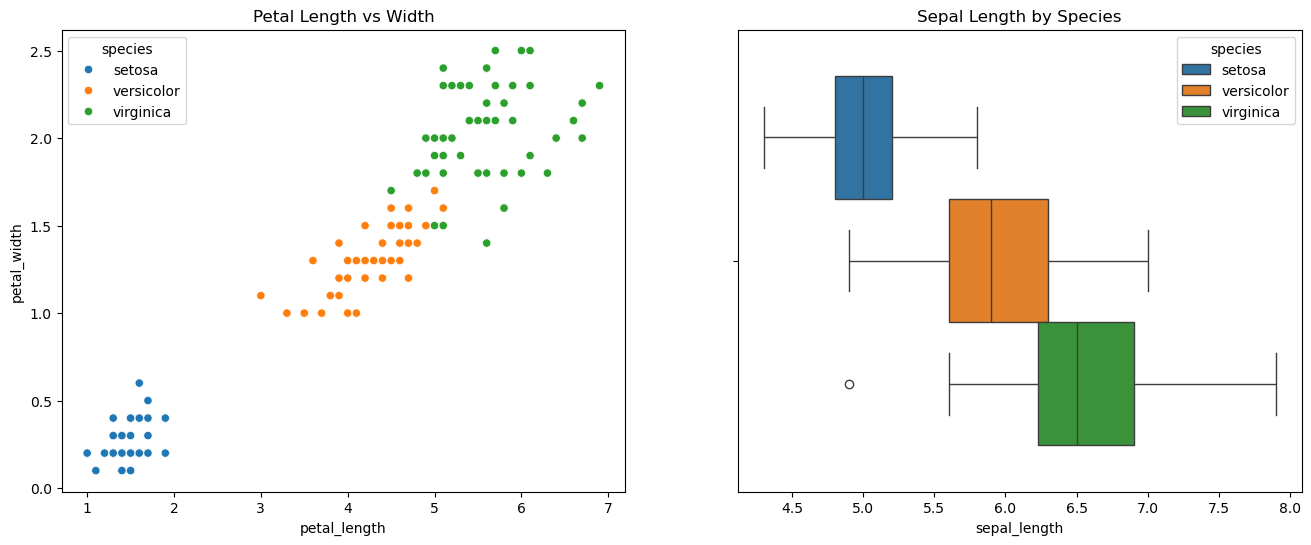

In [193]:
df['sepal_length'].mean()
df['sepal_length'].std()
df['sepal_width'].mean()
df['sepal_width'].std()
df['petal_length'].mean()
df['petal_length'].std()
df['petal_width'].mean()
df['petal_width'].std()

df['petal_radio'] = df['petal_length'] / df['petal_width']

df.groupby('species')['petal_radio'].median().sort_values(ascending=False).head(1)

df[(df['sepal_length']>6.0) & (df['petal_width']< 2.0)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', ax=axes[0])
axes[0].set_title('Petal Length vs Width')

sns.boxplot(data=df, x='sepal_length', hue='species', ax=axes[1])
axes[1].set_title('Sepal Length by Species')
plt.show()

## Esercizio 5

Usa il dataset `tips`, disponibile tramite `seaborn.load_dataset("tips")`.

1. Quante righe e colonne ha il dataset? Quali sono i tipi di dato per ogni colonna?

2. Controlla se ci sono valori mancanti o righe duplicate. Rimuovile se presenti.

3. Crea una nuova colonna `tip_percentage` definita come:
   $$\texttt{tip\_percentage} = \frac{\texttt{tip}}{\texttt{total\_bill}} \times 100$$

4. Calcola la **percentuale media di mancia** per:
   - giorno della settimana (`day`)
   - sesso del pagante (`sex`)

5. Riempi eventuali valori mancanti in `tip_percentage` con la media della colonna.

6. Visualizza la **distribuzione della percentuale di mancia** con un istogramma.

7. Confronta la distribuzione della `tip_percentage` tra **fumatori e non fumatori** con un violinplot.

💡 *Suggerimento*: `sns.violinplot(data=df, x='smoker', y='tip_percentage')`

In [199]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = sns.load_dataset('tips')
df

print(f"Dataset has {df.shape[1]} column and {df.shape[0]} rows")

df.isna().sum()
df = df.drop_duplicates()

df['tip_percentage'] = (df['tip'] / df['total_bill']) * 100

mean_by_day = df.groupby('day')['tip_percentage'].mean()
mean_by_sex = df.groupby('sex')['tip_percentage'].mean()

print(f"Current week days tips percetile:\n{mean_by_day.round(2)}")
print(f"On average, male pays {mean_by_sex.values[0].round(2)}% tips while woman pays the {mean_by_sex.values[1].round(2)}%")

#print(df.mean(axis=0, numeric_only=True))

df[df['tip_percentage'].isna() == True] = df['tip_percentage'].mean()

Dataset has 7 column and 244 rows
Current week days tips percetile:
day
Thur    16.14
Fri     16.99
Sat     15.32
Sun     16.69
Name: tip_percentage, dtype: float64
On average, male pays 15.77% tips while woman pays the 16.66%


,total_bill,tip,sex,smoker,day,time,size,tip_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.392697
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.358352
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.822232
242,17.82,1.75,Male,No,Sat,Dinner,2,9.820426


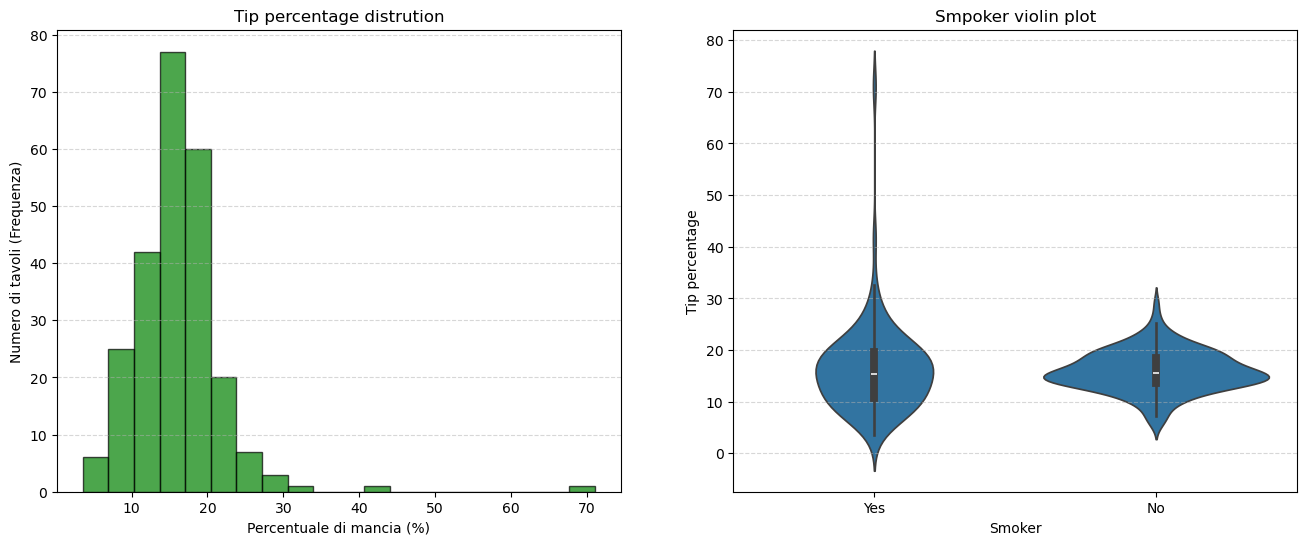

In [204]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

axes[0].hist(df['tip_percentage'], bins=20, color='green', edgecolor='black', alpha=0.7)
axes[0].set_title('Tip percentage distrution')
axes[0].set_xlabel('Percentuale di mancia (%)')
axes[0].set_ylabel('Numero di tavoli (Frequenza)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

sns.violinplot(data=df, x='smoker', y='tip_percentage', ax=axes[1])
axes[1].set_title('Smpoker violin plot')
axes[1].set_xlabel('Smoker')
axes[1].set_ylabel('Tip percentage')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Esercizio 6

Hai due array NumPy generati come segue:

```python
x = np.linspace(0, 2 * np.pi, 150)
y = 2.5 * np.sin(x) + np.random.normal(0, 0.3, 150)
```

Scrivi una funzione `fit_sinusoid(x, y)` che:

- usa `scipy.optimize.curve_fit` per eseguire un **fitting sinusoidale** del tipo `y = A * sin(x)`;  
- restituisce una tupla contenente:
  - il parametro ottimizzato `A`;
  - una stringa che descrive la curva trovata, ad esempio: `"y = 2.48 * sin(x)"`.

Esempio di output atteso: `(2.48, "y = 2.48 * sin(x)")`

Plotta i dati con rumore, la curva fittata e la curva ideale `y = 2.5 * sin(x)`, usando colori diversi e una legenda.

In [226]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as sp_opt

x = np.linspace(0, 2 * np.pi, 150)
y_data = 2.5 * np.sin(x) + np.random.normal(0, 0.3, 150)

ideal_eq = 2.5* np.sin(x)

def sinusoid_model(x, a):
    return a * np.sin(x)

def fit_sinusoid(x, y):
    params, cov = sp_opt.curve_fit(sinusoid_model, x, y)

    a_optimized = params[0]
    
    equation = f"y = {a_optimized:.3f} * sin(x)"

    return a_optimized, equation

a, eq = fit_sinusoid(x, y_data)
y_fit = sinusoid_model(x, a)

print(f"Equazione trovata: {eq}")

Equazione trovata: y = 2.512 * sin(x)


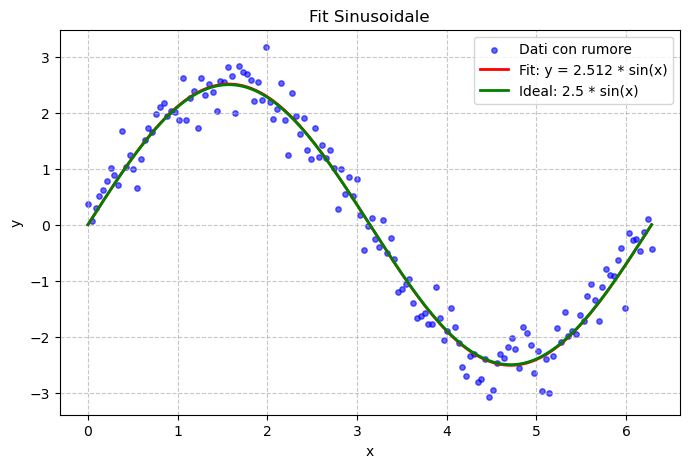

In [229]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y_data, label='Dati con rumore', color='blue', alpha=0.6, s=15)
plt.plot(x, y_fit, label=f'Fit: {eq}', color='red', linewidth=2)
plt.plot(x, ideal_eq ,label=f"Ideal: 2.5 * sin(x)", color='green', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Fit Sinusoidale')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Esercizio 7 *(Bonus)*

Usa il dataset `iris` già caricato nell'Esercizio 4.

1. Calcola la **matrice di correlazione** tra le variabili numeriche.

2. Visualizzala come **heatmap** con `seaborn.heatmap()`, mostrando i valori numerici nelle celle.

3. Quali due variabili risultano più correlate tra loro? Giustifica la risposta osservando il grafico.

💡 *Suggerimento*: `annot=True` in `sns.heatmap()` mostra i valori numerici.

In [ ]:
# Il tuo codice qui
